In [1]:
import pandas as pd 
df =pd.read_csv("../accepted_2007_to_2018Q4.csv.gz", compression="gzip", low_memory=False)
print("Before fix:",df.shape)
df.loc[df['loan_status'].str.contains('Fully Paid', na=False),'loan_status']='Fully Paid'
df.loc[df['loan_status'].str.contains('Charged Off', na=False), 'loan_status']='Charged Off'
df.loc[df['loan_status']=='Default','loan_status']='Charged Off'
terminal_status=['Fully Paid','Charged Off']
df=df[df['loan_status'].isin(terminal_status)].copy()
print("After fix",df.shape)
print(df['loan_status'].value_counts())


Before fix: (2260701, 151)
After fix (1348099, 151)
loan_status
Fully Paid     1078739
Charged Off     269360
Name: count, dtype: int64


In [4]:
df.to_pickle("accepted_filtered.pkl")

In [5]:
print(df['emp_length'].unique())

<StringArray>
['10+ years',   '3 years',   '4 years',   '6 years',   '7 years',   '8 years',
   '2 years',   '5 years',   '9 years',  '< 1 year',    '1 year',         nan]
Length: 12, dtype: str


In [6]:
emp_length_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

df['emp_length_num'] = df['emp_length'].map(emp_length_map)
df['emp_length_missing'] = df['emp_length'].isna().astype(int)
df['emp_length_num'] = df['emp_length_num'].fillna(-1)

print(df[['emp_length', 'emp_length_num', 'emp_length_missing']].drop_duplicates())

   emp_length  emp_length_num  emp_length_missing
0   10+ years            10.0                   0
4     3 years             3.0                   0
5     4 years             4.0                   0
8     6 years             6.0                   0
13    7 years             7.0                   0
15    8 years             8.0                   0
22    2 years             2.0                   0
25    5 years             5.0                   0
26    9 years             9.0                   0
27   < 1 year             0.0                   0
32     1 year             1.0                   0
75        NaN            -1.0                   1


In [22]:
df.to_pickle("accepted_filtered.pkl")

In [7]:
print(df['term'].unique())
print(df['int_rate'].unique())

<StringArray>
[' 36 months', ' 60 months']
Length: 2, dtype: str
[13.99 11.99 10.78 22.45 13.44  9.17  8.49  6.49 11.48 12.88 19.48  7.49
 19.89 14.85  5.32 17.97 24.24 15.77  9.8  17.27 18.49  7.91 23.13 20.5
 16.59 18.99 26.06 21.48  6.99 27.49 26.99 27.99 28.49  6.   25.09 28.99
 16.55  7.89 12.59 13.67 10.64  7.26 17.86 14.48 13.18  6.24  8.38 15.41
  9.76 21.99 16.99 25.99 17.57 18.2  22.99  6.89 11.22 19.99 27.31 20.99
 27.88 23.99 24.99 26.77 12.05  8.18  9.99 11.49 10.99 14.33 16.9  11.53
 18.55 14.65 13.33 12.69 18.25 19.19 12.29 15.61 25.78 19.52 24.5   6.39
  5.93  6.92  6.68 21.67 20.49 25.8  18.84 25.57 25.83 25.89  8.67 14.99
 17.14  8.19 10.49 11.44  6.03 12.39 15.59  9.49 13.66 14.31 12.99 15.99
 16.49 19.24 18.54  7.34 11.98 21.85 20.39  9.43  5.31  6.07 14.07 15.04
 18.45 10.9  13.58 17.47 16.01  7.96 23.87 30.65 24.84 25.81 10.41 12.61
  6.71 19.42  9.92 22.9  28.72 30.75 30.79 29.69 20.   30.94 30.17  6.08
 23.88 10.42  6.72 10.91 21.45 25.82 12.62  7.35 18.06 14.08

In [8]:
df['term_num']=df['term'].str.strip().str.replace(' months','',regex=False).astype(int)
print(df[['term', 'term_num']].drop_duplicates())

         term  term_num
0   36 months        36
2   60 months        60


In [9]:
print(df.columns.tolist())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

In [10]:
leakage_cols = [
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
    'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
    'collections_12_mths_ex_med', 'pymnt_plan', 'initial_list_status',
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status',
    'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount',
    'hardship_last_payment_amount', 'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage',
    'settlement_term', 'chargeoff_within_12_mths', 'delinq_amnt', 'acc_now_delinq',
    'tax_liens', 'tot_coll_amt'
]

useless_cols = [
    'id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code',
    'policy_code', 'funded_amnt', 'funded_amnt_inv', 'disbursement_method',
    'term', 'emp_length'
]

joint_cols = [
    'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'revol_bal_joint',
    'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line',
    'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc',
    'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts',
    'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med',
    'sec_app_mths_since_last_major_derog'
]

keep_clean = [
    'loan_amnt', 'int_rate', 'installment', 'grade', 'sub_grade',
    'home_ownership', 'annual_inc', 'verification_status', 'purpose',
    'addr_state', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'application_type',
    'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal',
    'bc_open_to_buy', 'bc_util', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_tl',
    'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl',
    'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0',
    'num_sats', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75',
    'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit'
]

already_cleaned = ['emp_length_num', 'emp_length_missing', 'term_num']

needs_cleanup = [
    'issue_d', 'earliest_cr_line', 'mths_since_last_delinq',
    'mths_since_last_record', 'mths_since_last_major_derog',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
    'mths_since_recent_inq', 'mths_since_recent_revol_delinq'
]

target = ['loan_status']

final_columns = keep_clean + already_cleaned + needs_cleanup + target

df = df[final_columns].copy()
print(df.shape)
print(df.columns.tolist())

(1348099, 60)
['loan_amnt', 'int_rate', 'installment', 'grade', 'sub_grade', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'application_type', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_tl', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'emp_length_num', 'emp_length_missing', 'term_num', 'issue_d', 'earliest_cr_line', 'mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog', 'mths_since_recent_bc', 'mths_since_recen

In [11]:
df.to_pickle("accepted_filtered.pkl")

In [12]:
print(df['issue_d'].unique())
print(df['earliest_cr_line'].unique())

<StringArray>
['Dec-2015', 'Nov-2015', 'Oct-2015', 'Sep-2015', 'Aug-2015', 'Jul-2015',
 'Jun-2015', 'May-2015', 'Apr-2015', 'Mar-2015',
 ...
 'Jan-2012', 'Sep-2016', 'Aug-2016', 'Jul-2016', 'Dec-2017', 'Nov-2017',
 'Oct-2017', 'Dec-2016', 'Nov-2016', 'Oct-2016']
Length: 139, dtype: str
<StringArray>
['Aug-2003', 'Dec-1999', 'Aug-2000', 'Jun-1998', 'Oct-1987', 'Jun-1990',
 'Feb-1999', 'Apr-2002', 'Nov-1994', 'Jun-1996',
 ...
        nan, 'Oct-1957', 'Nov-1953', 'Jul-1955', 'May-1953', 'Nov-1950',
 'Nov-1955', 'Feb-1957', 'Feb-1960', 'Dec-1951']
Length: 740, dtype: str


In [13]:
df ['issue_d']=pd.to_datetime(df['issue_d'],format='%b-%Y')
df['earliest_cr_line']=pd.to_datetime(df['earliest_cr_line'],format='%b-%Y')
df['credit_history_years']=(df['issue_d']-df['earliest_cr_line']).dt.days/365.25
print(df[['issue_d','earliest_cr_line','credit_history_years']])

           issue_d earliest_cr_line  credit_history_years
0       2015-12-01       2003-08-01             12.334018
1       2015-12-01       1999-12-01             16.000000
2       2015-12-01       2000-08-01             15.331964
4       2015-12-01       1998-06-01             17.500342
5       2015-12-01       1987-10-01             28.167009
...            ...              ...                   ...
2260688 2016-10-01       2004-07-01             12.251882
2260690 2016-10-01       2002-03-01             14.587269
2260691 2016-10-01       2011-06-01              5.336071
2260692 2016-10-01       1997-08-01             19.167693
2260697 2016-10-01       1999-07-01             17.253936

[1348099 rows x 3 columns]


In [14]:
df.to_pickle("accepted_filtered.pkl")

In [15]:
print("issue_d missing:", df['issue_d'].isna().sum())
print("earliest_cr_line missing:", df['earliest_cr_line'].isna().sum())
print("credit_history_years missing:", df['credit_history_years'].isna().sum())

issue_d missing: 0
earliest_cr_line missing: 29
credit_history_years missing: 29


In [16]:
df['credit_history_missing']=df['credit_history_years'].isna().astype(int)
df['credit_history_years']=df['credit_history_years'].fillna(-1)
print(df['credit_history_years'].isna().sum())
print(df['credit_history_missing'].sum())

0
29


In [17]:
mths_since_cols = [
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_last_major_derog',
    'mths_since_recent_bc',
    'mths_since_recent_bc_dlq',
    'mths_since_recent_inq',
    'mths_since_recent_revol_delinq'
]

for col in mths_since_cols:
    missing_count = df[col].isna().sum()
    missing_pct = round(missing_count / len(df) * 100, 1)
    print(col, "-", missing_count, "missing", f"({missing_pct}%)")

mths_since_last_delinq - 679960 missing (50.4%)
mths_since_last_record - 1118675 missing (83.0%)
mths_since_last_major_derog - 994342 missing (73.8%)
mths_since_recent_bc - 62972 missing (4.7%)
mths_since_recent_bc_dlq - 1029070 missing (76.3%)
mths_since_recent_inq - 176822 missing (13.1%)
mths_since_recent_revol_delinq - 898123 missing (66.6%)


In [18]:
for col in mths_since_cols:
    df[col+ '_missing']=df[col].isna().astype(int)
    df[col]=df[col].fillna(-1)

In [19]:
df.to_pickle("accepted_filtered.pkl")
print(df.shape)

(1348099, 69)


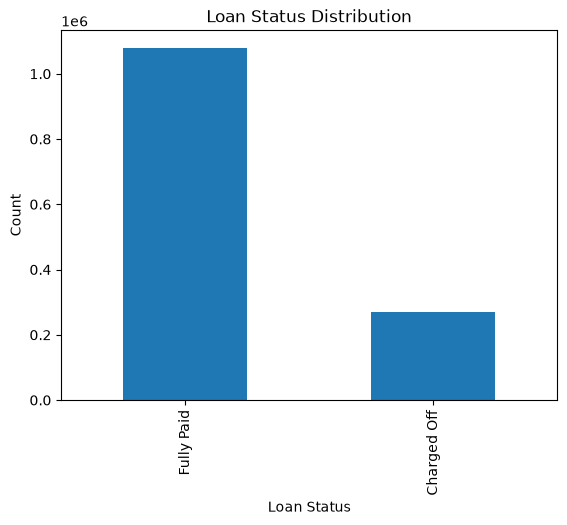

In [20]:
import matplotlib.pyplot as plt

df['loan_status'].value_counts().plot(kind='bar')
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

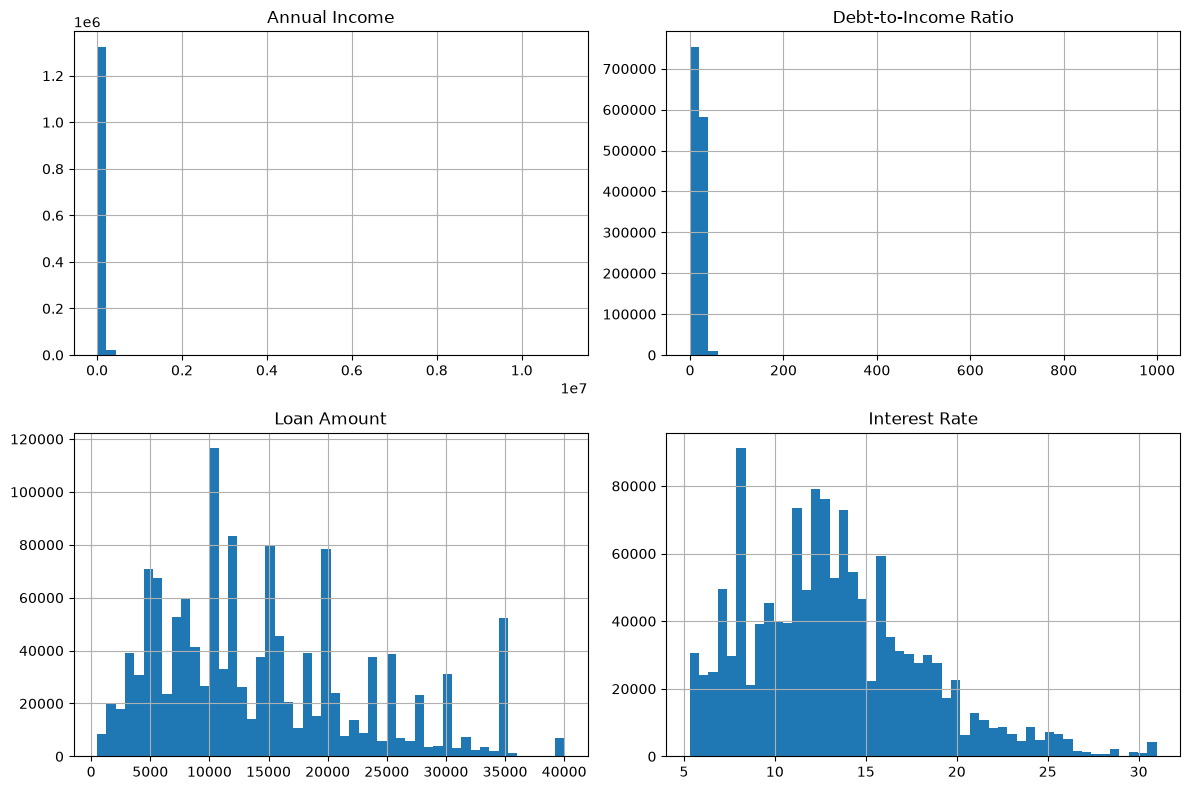

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df['annual_inc'].hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('Annual Income')

df['dti'].hist(bins=50, ax=axes[0,1])
axes[0,1].set_title('Debt-to-Income Ratio')

df['loan_amnt'].hist(bins=50, ax=axes[1,0])
axes[1,0].set_title('Loan Amount')

df['int_rate'].hist(bins=50, ax=axes[1,1])
axes[1,1].set_title('Interest Rate')

plt.tight_layout()
plt.show()

In [22]:
import os
print(os.getcwd())

C:\Users\soumya jain\loan-risk\notebooks


In [23]:
df = pd.read_pickle("../accepted_filtered.pkl")
print(df.shape)

(1348099, 71)


In [24]:
print(df['annual_inc'].describe())

count    1.348095e+06
mean     7.623774e+04
std      6.992274e+04
min      0.000000e+00
25%      4.575000e+04
50%      6.500000e+04
75%      9.000000e+04
max      1.099920e+07
Name: annual_inc, dtype: float64


In [7]:
print(df['annual_inc'].quantile([0.95, 0.99, 0.999]))

0.950    155000.0
0.990    251000.0
0.999    580000.0
Name: annual_inc, dtype: float64


In [25]:
cap_value = df['annual_inc'].quantile(0.99)
df['annual_inc_capped'] = df['annual_inc'].clip(upper=cap_value)

print(df['annual_inc_capped'].describe())

count    1.348095e+06
mean     7.456876e+04
std      4.222876e+04
min      0.000000e+00
25%      4.575000e+04
50%      6.500000e+04
75%      9.000000e+04
max      2.510000e+05
Name: annual_inc_capped, dtype: float64


In [26]:
df.to_pickle("../accepted_filtered.pkl")

In [27]:
default_by_grade = df.groupby('grade')['loan_status'].apply(lambda x: (x == 'Charged Off').mean() * 100)
print(default_by_grade.sort_index())

grade
A     6.043547
B    13.396269
C    22.443065
D    30.380299
E    38.431077
F    45.146412
G    49.667596
Name: loan_status, dtype: float64


In [28]:
default_by_purpose = df.groupby('purpose')['loan_status'].apply(lambda x: (x == 'Charged Off').mean() * 100)
print(default_by_purpose.sort_values(ascending=False))

purpose
small_business        29.864544
renewable_energy      23.717949
moving                23.399118
house                 21.910112
medical               21.845779
debt_consolidation    21.156657
other                 21.082745
educational           20.803783
vacation              19.198591
major_purchase        18.605753
home_improvement      17.756296
credit_card           16.932600
car                   14.721540
wedding               12.425532
Name: loan_status, dtype: float64


In [29]:
default_by_home = df.groupby('home_ownership')['loan_status'].apply(lambda x: (x == 'Charged Off').mean() * 100)
print(default_by_home.sort_values(ascending=False))

home_ownership
RENT        23.229649
OTHER       20.879121
OWN         20.631331
ANY         19.580420
MORTGAGE    17.229610
NONE        15.094340
Name: loan_status, dtype: float64


In [30]:
df['issue_year'] = df['issue_d'].dt.year
default_by_year = df.groupby('issue_year')['loan_status'].apply(lambda x: (x == 'Charged Off').mean() * 100)
print(default_by_year.sort_index())

issue_year
2007    26.202322
2008    20.727121
2009    13.690589
2010    14.014517
2011    15.178859
2012    16.197275
2013    15.595976
2014    18.449774
2015    20.185011
2016    23.285853
2017    23.132984
2018    15.756952
Name: loan_status, dtype: float64


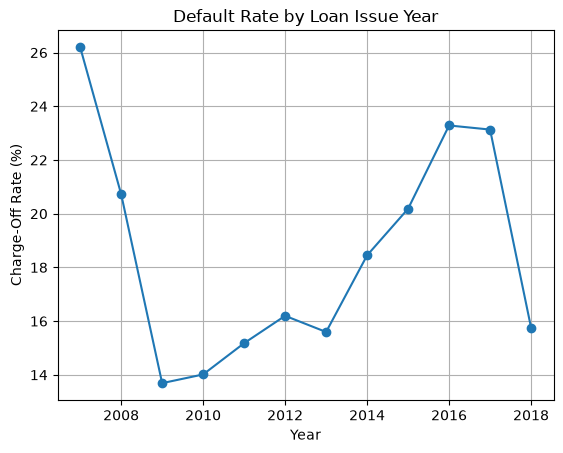

In [31]:
import matplotlib.pyplot as plt

default_by_year.sort_index().plot(kind='line', marker='o')
plt.title('Default Rate by Loan Issue Year')
plt.ylabel('Charge-Off Rate (%)')
plt.xlabel('Year')
plt.grid(True)
plt.show()

In [34]:
print("Before removing 2018:", df.shape)

df = df[df['issue_year'] != 2018].copy()

print("After removing 2018:", df.shape)
print(df['issue_year'].value_counts().sort_index())
df.to_pickle("../accepted_filtered.pkl")

Before removing 2018: (1291781, 72)
After removing 2018: (1291781, 72)
issue_year
2007       603
2008      2393
2009      5281
2010     12537
2011     21721
2012     53367
2013    134804
2014    223103
2015    375546
2016    293105
2017    169321
Name: count, dtype: int64


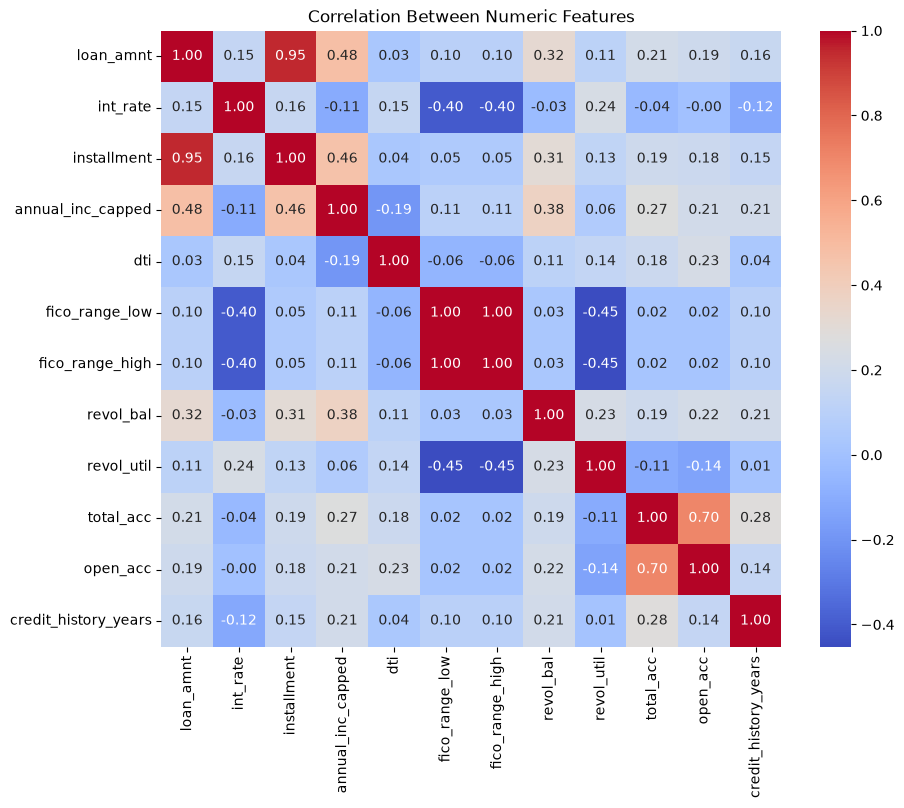

In [35]:
import seaborn as sns

numeric_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc_capped', 'dti',
                 'fico_range_low', 'fico_range_high', 'revol_bal', 'revol_util',
                 'total_acc', 'open_acc', 'credit_history_years']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Numeric Features")
plt.show()

In [3]:
print(df.columns.tolist())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

In [36]:
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2
df.to_pickle("../accepted_filtered.pkl")

In [2]:
import pandas as pd
df = pd.read_pickle("../accepted_filtered.pkl")

In [3]:
print(df.shape)
print(df.columns.tolist())

(1291781, 73)
['loan_amnt', 'int_rate', 'installment', 'grade', 'sub_grade', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'application_type', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_tl', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'emp_length_num', 'emp_length_missing', 'term_num', 'issue_d', 'earliest_cr_line', 'mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog', 'mths_since_recent_bc', 'mths_since_recen

In [4]:
df['loan_to_income']=df['loan_amnt']/df['annual_inc_capped']
df['installment_to_income']=df['installment']/(df['annual_inc_capped']/12)
print(df[['loan_amnt','annual_inc_capped','loan_to_income','installment','installment_to_income']].head(10))


    loan_amnt  annual_inc_capped  loan_to_income  installment  \
0      3600.0            55000.0        0.065455       123.03   
1     24700.0            65000.0        0.380000       820.28   
2     20000.0            63000.0        0.317460       432.66   
4     10400.0           104433.0        0.099585       289.91   
5     11950.0            34000.0        0.351471       405.18   
6     20000.0           180000.0        0.111111       637.58   
7     20000.0            85000.0        0.235294       631.26   
8     10000.0            85000.0        0.117647       306.45   
9      8000.0            42000.0        0.190476       263.74   
12     1400.0            64000.0        0.021875        47.10   

    installment_to_income  
0                0.026843  
1                0.151436  
2                0.082411  
4                0.033312  
5                0.143005  
6                0.042505  
7                0.089119  
8                0.043264  
9                0.075354  
12  

In [5]:
drop_cols=[
    'fico_range_low', 'fico_range_high',
    'earliest_cr_line',
    'issue_d','earlist_cr_line',
    'issue_year',
    'annual_inc',
]
df_model=df.drop(columns=drop_cols)
print(df_model.shape)
print(df_model.columns.tolist())

(1291781, 68)
['loan_amnt', 'int_rate', 'installment', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'application_type', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_tl', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'emp_length_num', 'emp_length_missing', 'term_num', 'mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'loan_status

In [8]:
categorical_cols = ['grade', 'sub_grade', 'home_ownership', 'verification_status', 
                     'purpose', 'addr_state', 'application_type']

for col in categorical_cols:
    print(col,"-",df_model[col].nunique(),"unique values")

grade - 7 unique values
sub_grade - 35 unique values
home_ownership - 6 unique values
verification_status - 3 unique values
purpose - 14 unique values
addr_state - 51 unique values
application_type - 2 unique values


In [9]:
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
df_model['grade_encoded'] = df_model['grade'].apply(lambda x: grade_order.index(x))

sub_grade_order = [f"{g}{n}" for g in grade_order for n in range(1, 6)]
df_model['sub_grade_encoded'] = df_model['sub_grade'].apply(lambda x: sub_grade_order.index(x))

onehot_cols = ['home_ownership', 'verification_status', 'purpose', 'addr_state', 'application_type']
df_model = pd.get_dummies(df_model, columns=onehot_cols, drop_first=True)

print(df_model.shape)

(1291781, 136)


In [10]:
df_model = df_model.drop(columns=['grade', 'sub_grade'])
print(df_model.shape)

(1291781, 134)


In [11]:
df_model.to_pickle("../model_ready.pkl")

In [15]:

print(df_model.shape)
print(df_model['target'].value_counts())

(1291781, 134)
target
0    1031295
1     260486
Name: count, dtype: int64


In [17]:
df_model['issue_d']=df.loc[df_model.index,'issue_d']

In [18]:
print(df_model['issue_d'].head(10))

0    2015-12-01
1    2015-12-01
2    2015-12-01
4    2015-12-01
5    2015-12-01
6    2015-12-01
7    2015-12-01
8    2015-12-01
9    2015-12-01
12   2015-12-01
Name: issue_d, dtype: datetime64[us]


In [19]:
df_model=df_model.sort_values('issue_d')
train=df_model[df_model['issue_d']<'2016-01-01']
test=df_model[df_model['issue_d']>='2016-01-01']
print("Train shape:",train.shape)
print("Test shape:",test.shape)
print("Train data range",train['issue_d'].min(),"to",train['issue_d'].max())
print("Test data range",test['issue_d'].min(),"to",test['issue_d'].max())


Train shape: (829355, 135)
Test shape: (462426, 135)
Train data range 2007-06-01 00:00:00 to 2015-12-01 00:00:00
Test data range 2016-01-01 00:00:00 to 2017-12-01 00:00:00


In [22]:
feature_cols=[col for col in df_model.columns if col not in ['target','issue_d']]
X_train=train[feature_cols]
Y_train=train['target']

X_test=test[feature_cols]
Y_test=test['target']

print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(829355, 133) (829355,)
(462426, 133) (462426,)


In [23]:
import pickle 
with open('../train_test_split.pkl','wb') as f:
    pickle.dump((X_train,Y_train,X_test,Y_test), f)
print("Saved.")

Saved.


In [26]:
missing_cols = missing_summary.index.tolist()

for col in missing_cols:
    X_train[col + '_missing'] = X_train[col].isna().astype(int)
    X_train[col] = X_train[col].fillna(-1)
    
    X_test[col + '_missing'] = X_test[col].isna().astype(int)
    X_test[col] = X_test[col].fillna(-1)

print("Remaining missing in X_train:", X_train.isna().sum().sum())
print("Remaining missing in X_test:", X_test.isna().sum().sum())

Remaining missing in X_train: 0
Remaining missing in X_test: 0


In [29]:
import numpy as np
for col in ['loan_to_income', 'installment_to_income']:
    X_train[col + '_inf'] = np.isinf(X_train[col]).astype(int)
    X_train[col] = X_train[col].replace([np.inf, -np.inf], -1)
    
    X_test[col + '_inf'] = np.isinf(X_test[col]).astype(int)
    X_test[col] = X_test[col].replace([np.inf, -np.inf], -1)

print("Remaining infinite in X_train:", np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum())
print("Remaining infinite in X_test:", np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum())

Remaining infinite in X_train: 0
Remaining infinite in X_test: 0


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_features = [
    'loan_amnt', 'int_rate', 'installment', 'dti', 'delinq_2yrs', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
    'pub_rec_bankruptcies', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths',
    'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_tl',
    'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl',
    'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats',
    'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'tot_hi_cred_lim',
    'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit',
    'emp_length_num', 'term_num', 'mths_since_last_delinq', 'mths_since_last_record',
    'mths_since_last_major_derog', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
    'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'credit_history_years',
    'annual_inc_capped', 'fico_avg', 'loan_to_income', 'installment_to_income',
    'grade_encoded', 'sub_grade_encoded'
]
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

In [33]:
print(X_train.columns.tolist())

['loan_amnt', 'int_rate', 'installment', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_tl', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'emp_length_num', 'emp_length_missing', 'term_num', 'mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'credit_history_years', 'credit_history_missing', 'mths_since_last_delinq_missing', 'mths_since_last_record_missing', 'mths_since_last

In [35]:
print(X_train_scaled[numeric_features].describe())

          loan_amnt      int_rate   installment           dti   delinq_2yrs  \
count  8.293550e+05  8.293550e+05  8.293550e+05  8.293550e+05  8.293550e+05   
mean  -3.609023e-17  1.328292e-15 -4.823325e-16  3.351915e-16 -1.477022e-17   
std    1.000001e+00  1.000001e+00  1.000001e+00  1.000001e+00  1.000001e+00   
min   -1.656030e+00 -1.780507e+00 -1.731270e+00 -2.263590e+00 -1.528463e+00   
25%   -7.610992e-01 -7.429642e-01 -7.249915e-01 -7.401566e-01 -3.627402e-01   
50%   -2.838029e-01 -3.534161e-02 -2.287339e-01 -5.723841e-02 -3.627402e-01   
75%    6.707895e-01  6.222240e-01  5.528870e-01  6.889572e-01 -3.627402e-01   
max    2.460650e+00  3.605160e+00  4.083077e+00  1.171277e+02  4.510045e+01   

       inq_last_6mths      open_acc       pub_rec     revol_bal    revol_util  \
count    8.293550e+05  8.293550e+05  8.293550e+05  8.293550e+05  8.293550e+05   
mean    -2.450280e-17 -7.463931e-17  1.007528e-17  2.564227e-17 -3.265213e-16   
std      1.000001e+00  1.000001e+00  1.000001

In [36]:
from sklearn.linear_model import LogisticRegression

model_scaled = LogisticRegression(max_iter=1000, class_weight='balanced')
model_scaled.fit(X_train_scaled, Y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [37]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred = model_scaled.predict(X_test_scaled)
y_pred_proba = model_scaled.predict_proba(X_test_scaled)[:, 1]

print("AUC-ROC:", roc_auc_score(Y_test, y_pred_proba))
print(classification_report(Y_test, y_pred))

AUC-ROC: 0.7135773550201447
              precision    recall  f1-score   support

           0       0.85      0.70      0.77    355005
           1       0.38      0.61      0.46    107421

    accuracy                           0.68    462426
   macro avg       0.62      0.65      0.62    462426
weighted avg       0.74      0.68      0.70    462426



In [42]:
import pickle

# Save the trained scaled model (overwrites the old one, ensuring it's the correct, final version)
with open('../baseline_logistic_model.pkl', 'wb') as f:
    pickle.dump(model_scaled, f)

# Save the scaler - critical, you'll need this exact one later for new predictions
with open('../scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the corrected + scaled train/test data together
with open('../train_test_final.pkl', 'wb') as f:
    pickle.dump((X_train, Y_train, X_test, Y_test, X_train_scaled, X_test_scaled), f)

print("Everything saved.")

Everything saved.


In [44]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
from xgboost import XGBClassifier
xgb_model=XGBClassifier(
    n_estimators=200,
max_depth=5,
learning_rate=0.1,
scale_pos_weight=(Y_train.value_counts()[0]/Y_train.value_counts()[1]),
eval_metric='auc',
random_state=42
)
xgb_model.fit(X_train,Y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [52]:
Y_pred_xgb=xgb_model.predict(X_test)
Y_pred_proba_xgb=xgb_model.predict_proba(X_test)[:,1]
print("XGBoost AUC-ROC:", roc_auc_score(Y_test,Y_pred_proba_xgb))
print(classification_report(Y_test,Y_pred_xgb))

XGBoost AUC-ROC: 0.7209850743982473
              precision    recall  f1-score   support

           0       0.86      0.67      0.76    355005
           1       0.37      0.65      0.47    107421

    accuracy                           0.67    462426
   macro avg       0.62      0.66      0.61    462426
weighted avg       0.75      0.67      0.69    462426



In [54]:
import pickle
with open('../xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("XGBoost model saved.")

XGBoost model saved.


In [55]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
    --------------------------------------- 0.0/1.4 MB 435.7 kB/s eta 0:00:04
   - -------------------------------------- 0.0/1.4 MB 487.6 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.4 MB 901.1 kB/s eta 0:00:02
   ---- ----------------------------------- 0.2/1.4 MB 913.1 kB/s eta 0:00:02
   ----- ---------------------------------- 0.2/1.4 MB 908.0 kB/s eta 0:00:02
   ------ --------------------------------- 0.2/1.4 MB 901.1 kB/s eta 0:00:02
   -------- ------------------------------- 0.3/1.4 MB 850.6 kB/s eta 0:00:02
   --------- ------------------------------ 0.3/1.4 MB 863.3 kB/s eta 0:00:02
   --------- ------------------------------ 0.3/1.4 MB 819.2 kB/s eta 0:00:02
   ---------- ----------------------------- 0.4/1.4 MB 849.3 kB/s eta 0:00:02
   ------------ --------------------------- 0.4/1.4 MB 917.0 kB/s eta 0:00:02
   -


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
from lightgbm import LGBMClassifier
lgbm_model=LGBMClassifier(
    n_estimator=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=(Y_train.value_counts()[0]/Y_train.value_counts()[1]),
    random_state=42
)
lgbm_model.fit(X_train,Y_train)

[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Info] Number of positive: 153065, number of negative: 676290
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.143627 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7404
[LightGBM] [Info] Number of data points in the train set: 829355, number of used features: 164
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.184559 -> initscore=-1.485759
[LightGBM] [Info] Start training from score -1.485759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

,max_depth,5
,random_state,42
,n_estimator,200
,scale_pos_weight,4.418319014797635
,boosting_type,'gbdt'
,num_leaves,31
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [61]:
y_pred_lgbm = lgbm_model.predict(X_test)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

print("LightGBM AUC-ROC:", roc_auc_score(Y_test, y_pred_proba_lgbm))
print(classification_report(Y_test, y_pred_lgbm))

[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Warning] Unknown parameter: n_estimator
LightGBM AUC-ROC: 0.7176978700203143
              precision    recall  f1-score   support

           0       0.86      0.66      0.75    355005
           1       0.37      0.65      0.47    107421

    accuracy                           0.66    462426
   macro avg       0.62      0.66      0.61    462426
weighted avg       0.75      0.66      0.68    462426



In [62]:
import pickle

with open('../lightgbm_model.pkl', 'wb') as f:
    pickle.dump(lgbm_model, f)
model_comparison = {
    'Logistic Regression': {'AUC': 0.7137, 'Recall_1': 0.61, 'Precision_1': 0.38},
    'XGBoost': {'AUC': 0.7210, 'Recall_1': 0.65, 'Precision_1': 0.37},
    'LightGBM': {'AUC': 0.7177, 'Recall_1': 0.65, 'Precision_1': 0.37},
}
import json
with open('../model_comparison.json', 'w') as f:
    json.dump(model_comparison, f, indent=2)

print("Saved.")

Saved.


In [64]:
grade_related=['grade_encoded','sub_grade_encoded','int_rate']
X_train_nogade=X_train.drop(columns=grade_related)
X_test_nogade=X_test.drop(columns=grade_related)

xgb_model_nogade=XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=(Y_train.value_counts()[0]/Y_train.value_counts()[1]),
    eval_metric='auc',
    random_state=42
)
xgb_model_nogade.fit(X_train_nogade,Y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [66]:
Y_pred_nogade=xgb_model_nogade.predict(X_test_nogade)
Y_pred_proba_nogade=xgb_model_nogade.predict_proba(X_test_nogade)[:,1]
print("XGBoost (no grade) AUC-ROC", roc_auc_score(Y_test,Y_pred_proba_nogade))
print(classification_report(Y_test,Y_pred_nogade))

XGBoost (no grade) AUC-ROC 0.7153796223396387
              precision    recall  f1-score   support

           0       0.86      0.69      0.76    355005
           1       0.38      0.62      0.47    107421

    accuracy                           0.67    462426
   macro avg       0.62      0.65      0.62    462426
weighted avg       0.74      0.67      0.69    462426



In [67]:
with open('../xgboost_model_nogade.pkl', 'wb') as f:
    pickle.dump(xgb_model_nogade, f)

print("Saved.")

Saved.


In [71]:
# looks inside the xgb model 
explainer=shap.TreeExplainer(xgb_model)
# sets up the tool which calculated feature disdtribution
X_test_sample=X_test.sample(2000,random_state=42)
# randomly picks out 2000 shap values
shap_values=explainer.shap_values(X_test_sample)
# calculates how mch each feautre contributed 
print(shap_values.shape)

(2000, 171)


In [73]:
print(X_train.shape)
print(X_test.shape)

(829355, 171)
(462426, 171)


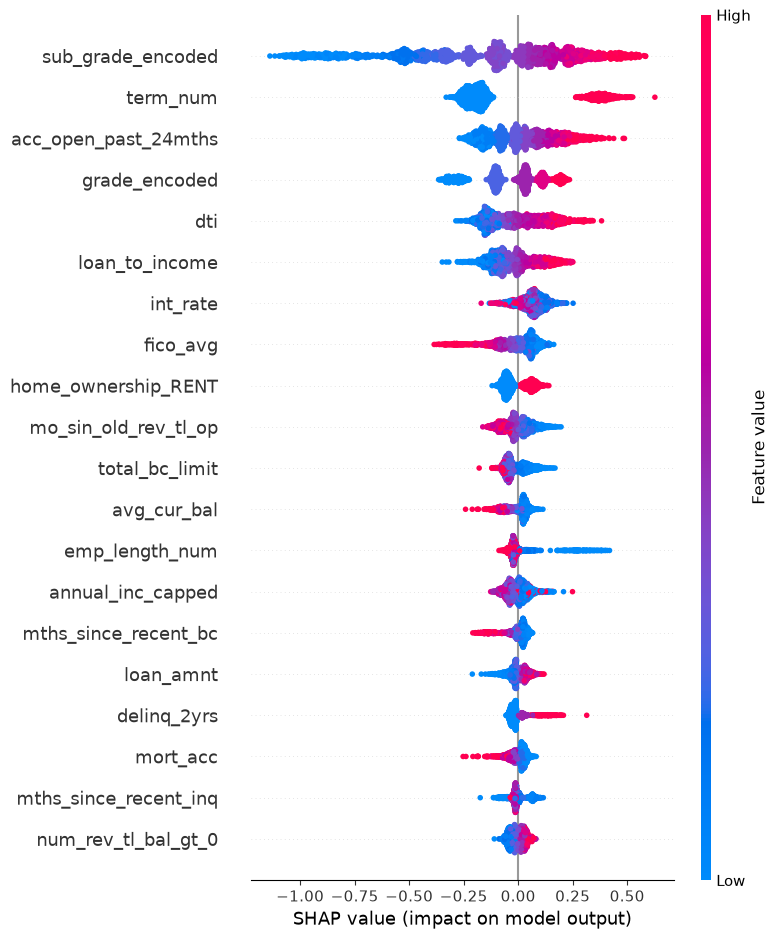

In [76]:
#ranks feature by importance 
import matplotlib.pyplot as plt 
shap.summary_plot(shap_values,X_test_sample)

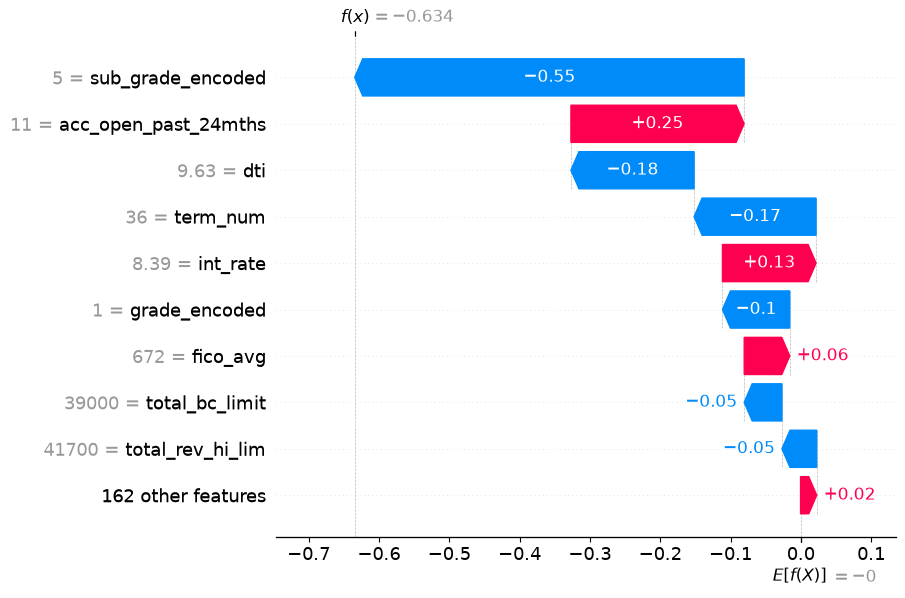

In [77]:
# tells the contribution of each for one spsecific loan at first row 
sample_idx = 0

shap.plots.waterfall(shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_sample.iloc[sample_idx],
    feature_names=X_test_sample.columns.tolist()
))

In [5]:
import pandas as pd
import pickle
from xgboost import XGBClassifier
import shap

with open('../train_test_final.pkl', 'rb') as f:
    X_train, Y_train, X_test, Y_test, X_train_scaled, X_test_scaled = pickle.load(f)

print("Data loaded:", X_train.shape, X_test.shape)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=(Y_train.value_counts()[0] / Y_train.value_counts()[1]),
    eval_metric='auc',
    random_state=42
)
xgb_model.fit(X_train, Y_train)
print("Model trained.")

explainer = shap.TreeExplainer(xgb_model)
print("Explainer built.")

with open('../xgboost_final_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('../shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

feature_columns = X_train.columns.tolist()
with open('../feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("Model artifacts saved for API use.")

C:\Users\soumya jain\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data loaded: (829355, 171) (462426, 171)
Model trained.
Explainer built.
Model artifacts saved for API use.


In [7]:
import os
print(os.listdir('..'))

['.git', '.gitignore', '.ipynb_checkpoints', 'accepted_2007_to_2018Q4.csv.gz', 'accepted_filtered.pkl', 'baseline_logistic_model.pkl', 'decisions.md', 'feature_columns.pkl', 'lightgbm_model.pkl', 'model_comparison.json', 'model_ready.pkl', 'notebooks', 'README.md', 'rejected_2007_to_2018Q4.csv.gz', 'requirements.txt', 'scaler.pkl', 'shap_explainer.pkl', 'train_test_final.pkl', 'train_test_split.pkl', 'xgboost_final_model.pkl', 'xgboost_model.pkl', 'xgboost_model_nogade.pkl']


In [3]:
import pickle
with open('../feature_columns.pkl', 'rb') as f:
    feature_columns = pickle.load(f)
print(len(feature_columns))
for col in feature_columns:
    print(f"    {col}: float = 0")

171
    loan_amnt: float = 0
    int_rate: float = 0
    installment: float = 0
    dti: float = 0
    delinq_2yrs: float = 0
    inq_last_6mths: float = 0
    open_acc: float = 0
    pub_rec: float = 0
    revol_bal: float = 0
    revol_util: float = 0
    total_acc: float = 0
    mort_acc: float = 0
    pub_rec_bankruptcies: float = 0
    tot_cur_bal: float = 0
    total_rev_hi_lim: float = 0
    acc_open_past_24mths: float = 0
    avg_cur_bal: float = 0
    bc_open_to_buy: float = 0
    bc_util: float = 0
    mo_sin_old_rev_tl_op: float = 0
    mo_sin_rcnt_tl: float = 0
    num_actv_bc_tl: float = 0
    num_actv_rev_tl: float = 0
    num_bc_sats: float = 0
    num_bc_tl: float = 0
    num_il_tl: float = 0
    num_op_rev_tl: float = 0
    num_rev_accts: float = 0
    num_rev_tl_bal_gt_0: float = 0
    num_sats: float = 0
    num_tl_op_past_12m: float = 0
    pct_tl_nvr_dlq: float = 0
    percent_bc_gt_75: float = 0
    tot_hi_cred_lim: float = 0
    total_bal_ex_mort: float = 0
    t

In [4]:
import pickle

with open('../train_test_final.pkl', 'rb') as f:
    X_train, Y_train, X_test, Y_test, X_train_scaled, X_test_scaled = pickle.load(f)

feature_medians = X_train.median().to_dict()

with open('../feature_medians.pkl', 'wb') as f:
    pickle.dump(feature_medians, f)

print("Medians saved.")
print(list(feature_medians.items())[:10])  # quick peek



Medians saved.
[('loan_amnt', 12000.0), ('int_rate', 12.99), ('installment', 377.19), ('dti', 17.48), ('delinq_2yrs', 0.0), ('inq_last_6mths', 0.0), ('open_acc', 11.0), ('pub_rec', 0.0), ('revol_bal', 11580.0), ('revol_util', 55.5)]


In [1]:
pip install streamlit requests

     ---------------------------------------- 0.0/44.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/44.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/44.3 kB ? eta -:--:--
     ------------------------------------ --- 41.0/44.3 kB 1.9 MB/s eta 0:00:01
     ---------------------------------------- 44.3/44.3 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---------------------------------------- 0.1/10.5 MB 7.5 MB/s eta 0:00:02
    --------------------------------------- 0.2/10.5 MB 5.9 MB/s eta 0:00:02
    --------------------------------------- 0.2/10.5 MB 5.9 MB/s eta 0:00:02
    --------------------------------------- 0.2/10.5 MB 2.1 MB/s eta 0:00:05
    --------------------------------------- 0.2/10.5 MB 2.1 MB/s eta 0:00:05
   - -------------------------------------- 0.3/10.5 MB 1.3 MB/s eta 0:00:09
   - -------------------------------------- 0.3/10.5 MB 1.3 MB/s eta 0:00:09
   - ----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastapi 0.100.0 requires starlette<0.28.0,>=0.27.0, but you have starlette 1.3.1 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install --upgrade fastapi


   ---------------------------------------- 0.0/132.0 kB ? eta -:--:--
   --- ------------------------------------ 10.2/132.0 kB ? eta -:--:--
   --------- ----------------------------- 30.7/132.0 kB 220.2 kB/s eta 0:00:01
   --------- ----------------------------- 30.7/132.0 kB 220.2 kB/s eta 0:00:01
   ----------------------------------- -- 122.9/132.0 kB 602.4 kB/s eta 0:00:01
   ----------------------------------- -- 122.9/132.0 kB 602.4 kB/s eta 0:00:01
   -------------------------------------- 132.0/132.0 kB 486.9 kB/s eta 0:00:00
  Attempting uninstall: fastapi
    Found existing installation: fastapi 0.100.0
    Uninstalling fastapi-0.100.0:
      Successfully uninstalled fastapi-0.100.0
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
